# Market Data Ingestion
Downloads 5 years of daily OHLCV data for AAPL, MSFT, NVDA, GOOGL, AMZN and the ^VIX index via yfinance.
All series are aligned on a common date index; gaps from market holidays are forward-filled.

In [1]:
import yfinance as yf
import pandas as pd
from datetime import date, timedelta

# ── Configuration ──────────────────────────────────────────────────────────────
TICKERS   = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN", "^VIX"]
END_DATE  = date.today()
START_DATE = END_DATE - timedelta(days=5 * 365)  # ~5 calendar years

print(f"Fetching data from {START_DATE} to {END_DATE} for: {TICKERS}")

# ── Download ───────────────────────────────────────────────────────────────────
# group_by='ticker' gives a MultiIndex (ticker, field) column structure.
# auto_adjust=True returns split/dividend-adjusted prices so OHLC are comparable
# across the full history.
raw = yf.download(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    group_by="ticker",
    auto_adjust=True,
    progress=True,
)

# ── Extract adjusted-close prices into a flat DataFrame ───────────────────────
# Each column corresponds to one instrument; the index is the shared trading-day
# calendar (union of all tickers' available dates).
close_frames = {}
for ticker in TICKERS:
    try:
        col_name = ticker.lstrip("^")          # strip ^ so column is "VIX"
        close_frames[col_name] = raw[ticker]["Close"]
    except KeyError:
        print(f"  WARNING: 'Close' not found for {ticker} — skipping.")

prices = pd.DataFrame(close_frames)

# ── Align & clean ──────────────────────────────────────────────────────────────
# 1. Ensure the index is a proper DatetimeIndex (yfinance usually returns one,
#    but an explicit cast is defensive and preserves tz-naivety consistently).
prices.index = pd.to_datetime(prices.index)
prices.index.name = "Date"

# 2. Sort chronologically (download should already be sorted, but be explicit).
prices.sort_index(inplace=True)

# 3. Forward-fill: propagates the last known price into any NaN slot caused by
#    holidays, exchange closures, or staggered listing dates.  A leading NaN
#    (before a ticker's first trading day) is left as-is intentionally — there
#    is no prior value to carry forward and back-filling would introduce look-
#    ahead bias.
prices.ffill(inplace=True)

# ── Diagnostics ────────────────────────────────────────────────────────────────
remaining_nulls = prices.isnull().sum()
print(f"\nShape after alignment: {prices.shape}  (rows × tickers)")
print(f"Date range : {prices.index[0].date()}  →  {prices.index[-1].date()}")
print(f"\nResidual NaNs per column (pre-first-trade gaps only):\n{remaining_nulls}")

# ── Preview ────────────────────────────────────────────────────────────────────
print("\nFirst five rows of cleaned price DataFrame:")
prices.head()

Fetching data from 2021-04-16 to 2026-04-15 for: ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'AMZN', '^VIX']


[*********************100%***********************]  6 of 6 completed


Shape after alignment: (1254, 6)  (rows × tickers)
Date range : 2021-04-16  →  2026-04-14

Residual NaNs per column (pre-first-trade gaps only):
AAPL     0
MSFT     0
NVDA     0
GOOGL    0
AMZN     0
VIX      0
dtype: int64

First five rows of cleaned price DataFrame:


,AAPL,MSFT,NVDA,GOOGL,AMZN,VIX
Date,,,,,,
2021-04-16,130.671280,250.195587,15.872496,113.201889,169.972000,16.250000
2021-04-19,131.333542,248.276459,15.323131,113.549522,168.600494,17.290001
2021-04-20,129.648560,247.815857,15.133109,113.016418,166.734497,18.680000
2021-04-21,130.028381,250.042053,15.321883,112.983704,168.100998,17.500000
2021-04-22,128.508987,246.769943,14.812917,111.702782,165.451996,18.709999


## Amihud Illiquidity Metric

Calculates the Amihud (2002) illiquidity ratio for each equity:

$$\text{ILLIQ}_t = \frac{|R_t|}{P_t \times V_t}$$

where $R_t$ is the log return, $P_t$ is the adjusted closing price, and $V_t$ is share volume.
A natural-log transformation (`log1p`) is then applied to compress the heavy right tail
and stabilise variance for time-series modelling.  
^VIX is excluded — it is a volatility index with no tradeable share volume.

In [2]:
import numpy as np

# ── Equity universe (VIX has no share volume — excluded by design) ─────────────
EQUITY_TICKERS = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN"]

# ── Extract volume from the already-downloaded `raw` MultiIndex object ─────────
volume_frames = {}
for ticker in EQUITY_TICKERS:
    try:
        volume_frames[ticker] = raw[ticker]["Volume"]
    except KeyError:
        print(f"  WARNING: 'Volume' not found for {ticker} — skipping.")

volume = pd.DataFrame(volume_frames)
volume.index = pd.to_datetime(volume.index)
volume.index.name = "Date"
volume.sort_index(inplace=True)
volume.ffill(inplace=True)

# Isolate close prices for equities only (drop VIX column).
equity_prices = prices[EQUITY_TICKERS].copy()

# ── Tiny floor constant ────────────────────────────────────────────────────────
# Raw Amihud scores sit around 1e-12. log1p(x) ≈ x for x << 1, so it rounded
# every score to zero. We switch to log(raw_illiq + EPS) which maps 1e-12 to
# roughly -27.6 — a finite, meaningful negative number on the log scale.
# EPS = 1e-25 is well below the smallest observed score (~1e-14 for large-caps)
# so it acts purely as a -inf guard and does not distort the distribution.
EPS = 1e-25


def amihud_illiquidity(
    close: pd.Series,
    vol: pd.Series,
    log_transform: bool = True,
) -> pd.Series:
    """
    Compute the Amihud (2002) illiquidity ratio for a single instrument.

    Parameters
    ----------
    close         : pd.Series — adjusted closing price time series.
    vol           : pd.Series — daily share volume time series.
    log_transform : bool      — if True, apply log(raw + EPS) to map the
                                distribution to a usable numeric range for
                                time-series modelling.

    Returns
    -------
    pd.Series of illiquidity scores aligned to the input index.

    Notes
    -----
    * Log returns are used for |R_t| rather than simple returns; they are
      additive over time and better-behaved for downstream regression models.
    * Dollar volume (P_t * V_t) normalises raw share counts into USD notional,
      making scores comparable across tickers with different price levels.
    * Days where close <= 0 or volume == 0 produce undefined ratios; they are
      replaced with NaN and forward-filled to avoid distorting the time series.
    * log1p was previously used but rounds to zero when raw scores are ~1e-12
      because log1p(x) ≈ x for x << 1. log(x + EPS) correctly maps 1e-12 to
      ≈ -27.6, giving the series real variance for PCA and ARIMAX modelling.
    """
    # Log return: ln(P_t / P_{t-1}); first observation becomes NaN.
    log_ret = np.log(close / close.shift(1))
    abs_ret = log_ret.abs()

    # Dollar volume denominator.
    dollar_vol = close * vol

    # Raw Amihud ratio; mask degenerate rows (zero/missing denominator).
    raw_illiq = abs_ret / dollar_vol
    raw_illiq[dollar_vol <= 0] = np.nan
    raw_illiq.ffill(inplace=True)

    if log_transform:
        # log(x + EPS): EPS guards against log(0) = -inf on zero-return days
        # while having negligible effect on scores in the 1e-14 to 1e-10 range.
        return np.log(raw_illiq + EPS)
    return raw_illiq


# ── Apply to all equity tickers ────────────────────────────────────────────────
illiq_scores = pd.DataFrame(
    {
        ticker: amihud_illiquidity(
            close=equity_prices[ticker],
            vol=volume[ticker],
            log_transform=True,
        )
        for ticker in EQUITY_TICKERS
    }
)
illiq_scores.index.name = "Date"

# ── Diagnostics ────────────────────────────────────────────────────────────────
print("Amihud Log-Illiquidity Scores — descriptive statistics:")
print(illiq_scores.describe().round(4))
print(f"\nResidual NaNs:\n{illiq_scores.isnull().sum()}")

# ── Preview ────────────────────────────────────────────────────────────────────
print("\nFirst five rows of log-transformed Amihud illiquidity scores:")
illiq_scores.head()

Amihud Log-Illiquidity Scores — descriptive statistics:
            AAPL       MSFT       NVDA      GOOGL       AMZN
count  1253.0000  1253.0000  1253.0000  1253.0000  1253.0000
mean    -28.1199   -27.8125   -27.8411   -26.9845   -27.5514
std       1.7982     1.4158     1.7519     1.6267     1.8486
min     -57.5646   -57.5646   -57.5646   -57.5646   -57.5646
25%     -28.6151   -28.3827   -28.4962   -27.5142   -28.0420
50%     -27.8385   -27.5787   -27.6902   -26.7383   -27.2257
75%     -27.2942   -26.9856   -26.9003   -26.1891   -26.7154
max     -26.0294   -25.6518   -25.1339   -24.8970   -25.4627

Residual NaNs:
AAPL     1
MSFT     1
NVDA     1
GOOGL    1
AMZN     1
dtype: int64

First five rows of log-transformed Amihud illiquidity scores:


,AAPL,MSFT,NVDA,GOOGL,AMZN
Date,,,,,
2021-04-16,NaN,NaN,NaN,NaN,NaN
2021-04-19,-28.526660,-27.341131,-25.893347,-27.745881,-27.757066
2021-04-20,-27.581773,-28.598813,-26.727680,-27.006018,-27.390141
2021-04-21,-28.749495,-27.233326,-26.313951,-29.834394,-27.537576
2021-04-22,-27.552618,-26.896417,-25.525680,-26.189439,-27.010396


## Exploratory Data Analysis

### Visualisation 1 — Correlation Heatmap of Log-Illiquidity Scores
Pearson correlations across the five equities reveal whether illiquidity shocks are idiosyncratic or sector-wide.  
High off-diagonal values suggest common liquidity drivers (e.g. macro stress, index rebalancing).

### Visualisation 2 — Average Tech Illiquidity vs. VIX (Dual-Axis)
Overlays the equal-weighted mean log-illiquidity of the five stocks against the VIX closing level.  
A strong co-movement would support using VIX as a leading liquidity-stress indicator in the model.

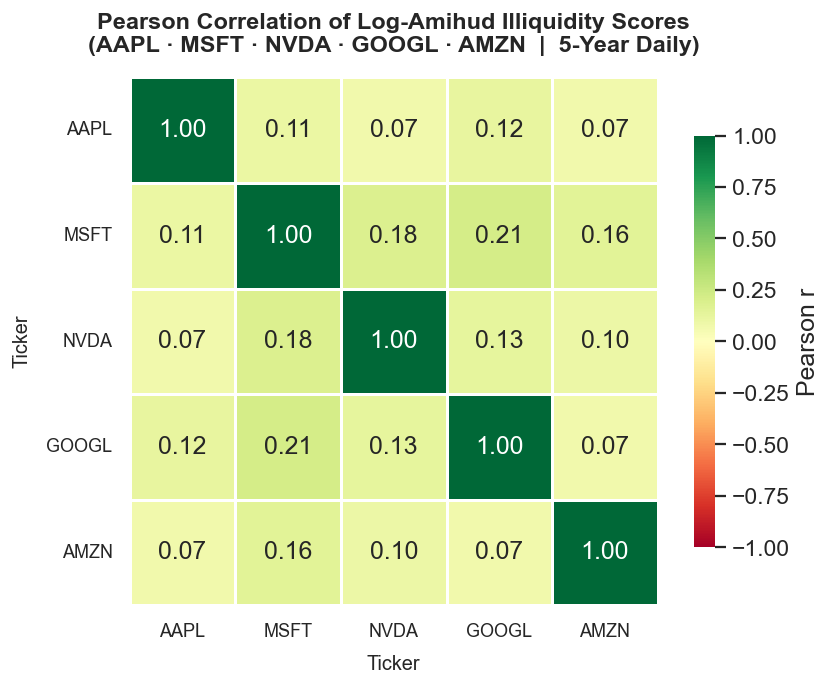

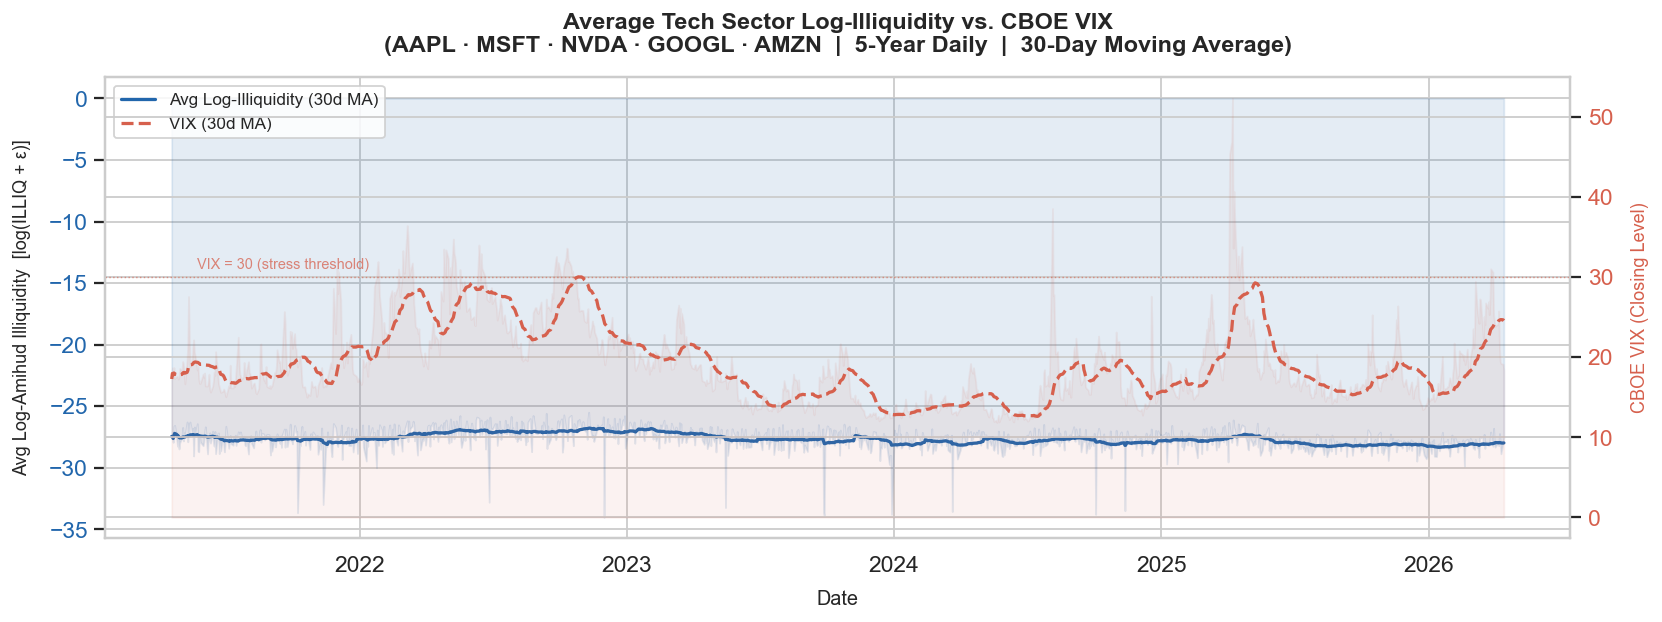

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Global aesthetics ──────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams["figure.dpi"] = 130

# ══════════════════════════════════════════════════════════════════════════════
# VISUALISATION 1 — Pearson Correlation Heatmap of Log-Illiquidity Scores
# ══════════════════════════════════════════════════════════════════════════════
corr_matrix = illiq_scores.corr(method="pearson")

fig1, ax1 = plt.subplots(figsize=(7, 5.5))

sns.heatmap(
    corr_matrix,
    ax=ax1,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    linewidths=0.6,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.78, "label": "Pearson r"},
)

ax1.set_title(
    "Pearson Correlation of Log-Amihud Illiquidity Scores\n"
    "(AAPL · MSFT · NVDA · GOOGL · AMZN  |  5-Year Daily)",
    fontsize=13, fontweight="bold", pad=14,
)
ax1.set_xlabel("Ticker", fontsize=11, labelpad=8)
ax1.set_ylabel("Ticker", fontsize=11, labelpad=8)
ax1.tick_params(axis="both", labelsize=10, rotation=0)

fig1.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# VISUALISATION 2 — Dual-Axis: Average Tech Illiquidity vs. VIX
# ══════════════════════════════════════════════════════════════════════════════

avg_illiq = illiq_scores.mean(axis=1).rename("Avg Log-Illiquidity")
vix_series = prices["VIX"].copy()

combined = pd.concat([avg_illiq, vix_series], axis=1, join="inner")
combined.columns = ["Avg Log-Illiquidity", "VIX"]
combined.dropna(inplace=True)

WINDOW = 30
illiq_smooth = combined["Avg Log-Illiquidity"].rolling(WINDOW, min_periods=1).mean()
vix_smooth   = combined["VIX"].rolling(WINDOW, min_periods=1).mean()

fig2, ax_left = plt.subplots(figsize=(13, 5))
ax_right = ax_left.twinx()

ILLIQ_COLOR = "#2166AC"
VIX_COLOR   = "#D6604D"

ax_left.fill_between(combined.index, combined["Avg Log-Illiquidity"],
                     alpha=0.12, color=ILLIQ_COLOR, label="_nolegend_")
ax_left.plot(illiq_smooth.index, illiq_smooth,
             color=ILLIQ_COLOR, linewidth=1.8,
             label=f"Avg Log-Illiquidity ({WINDOW}d MA)")

ax_right.fill_between(combined.index, combined["VIX"],
                      alpha=0.08, color=VIX_COLOR, label="_nolegend_")
ax_right.plot(vix_smooth.index, vix_smooth,
              color=VIX_COLOR, linewidth=1.8, linestyle="--",
              label=f"VIX ({WINDOW}d MA)")

ax_left.set_title(
    "Average Tech Sector Log-Illiquidity vs. CBOE VIX\n"
    "(AAPL · MSFT · NVDA · GOOGL · AMZN  |  5-Year Daily  |  30-Day Moving Average)",
    fontsize=13, fontweight="bold", pad=14,
)
ax_left.set_xlabel("Date", fontsize=11, labelpad=8)
ax_left.set_ylabel("Avg Log-Amihud Illiquidity  [log(ILLIQ + ε)]", fontsize=10, labelpad=10)
ax_right.set_ylabel("CBOE VIX (Closing Level)", fontsize=10, labelpad=10, color=VIX_COLOR)

ax_left.tick_params(axis="y", labelcolor=ILLIQ_COLOR)
ax_right.tick_params(axis="y", labelcolor=VIX_COLOR)

ax_left.xaxis.set_major_locator(mdates.YearLocator())
ax_left.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_left.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
plt.setp(ax_left.xaxis.get_majorticklabels(), rotation=0, ha="center")

lines_left,  labels_left  = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right,
               loc="upper left", fontsize=9.5, framealpha=0.85)

ax_right.axhline(30, color=VIX_COLOR, linewidth=0.8, linestyle=":", alpha=0.6)
ax_right.annotate(
    "VIX = 30 (stress threshold)",
    xy=(combined.index[int(len(combined) * 0.02)], 31),
    fontsize=8, color=VIX_COLOR, alpha=0.75,
)

fig2.tight_layout()
plt.show()

## Time-Series Modelling — ARIMAX on the PC1 Liquidity Factor

**Pipeline:**
1. **PCA** — reduce the five log-illiquidity series to a single latent factor (PC1) that captures the dominant co-movement.
2. **ADF Test** — verify PC1 is stationary before fitting any ARIMA-family model; differencing order `d` is set accordingly.
3. **AIC Grid Search** — exhaustive search over `p ∈ [0,3]`, `d ∈ [0,1]`, `q ∈ [0,3]` to find the optimal ARIMAX order.
4. **ARIMAX Fit** — PC1 is the endogenous target; the daily VIX closing level is the exogenous regressor.
5. **Actual vs. Predicted Plot** — in-sample fit visualised over the most recent 60 trading days.

── PCA Explained Variance ──────────────────────────────────────────
  PC1: 30.10%  ◀ selected
  PC2: 18.97%  
  PC3: 18.45%  
  PC4: 17.30%  
  PC5: 15.18%  

  PC1 captures 30.10% of total log-illiquidity variance.

── Augmented Dickey-Fuller Test on PC1 ─────────────────────────────
  Test Statistic : -3.5241
  p-value        : 0.0074
  Lags Used      : 19
  Observations   : 1233
  Critical Values:
    1%: -3.4357
    5%: -2.8639
    10%: -2.5680

  RESULT: Reject H₀ — PC1 is STATIONARY (d = 0 is valid).

── Modelling window: 2021-04-19 → 2026-04-14
   Observations: 1253

── ARIMAX AIC Grid Search ──────────────────────────────────────────
  Search space: p ∈ [0, 1, 2, 3], d ∈ [0, 1], q ∈ [0, 1, 2, 3]
  Total candidates: 32

  Top 10 models by AIC:
 p  d  q         AIC
 0  1  1 3856.336326
 0  1  2 3857.215783
 1  1  1 3857.287129
 0  1  3 3857.907908
 2  1  1 3858.121821
 2  1  3 3858.433920
 3  1  1 3858.444396
 1  0  1 3860.180915
 1  1  2 3860.321710
 2  0  1 3861.094389

  ✔ Op

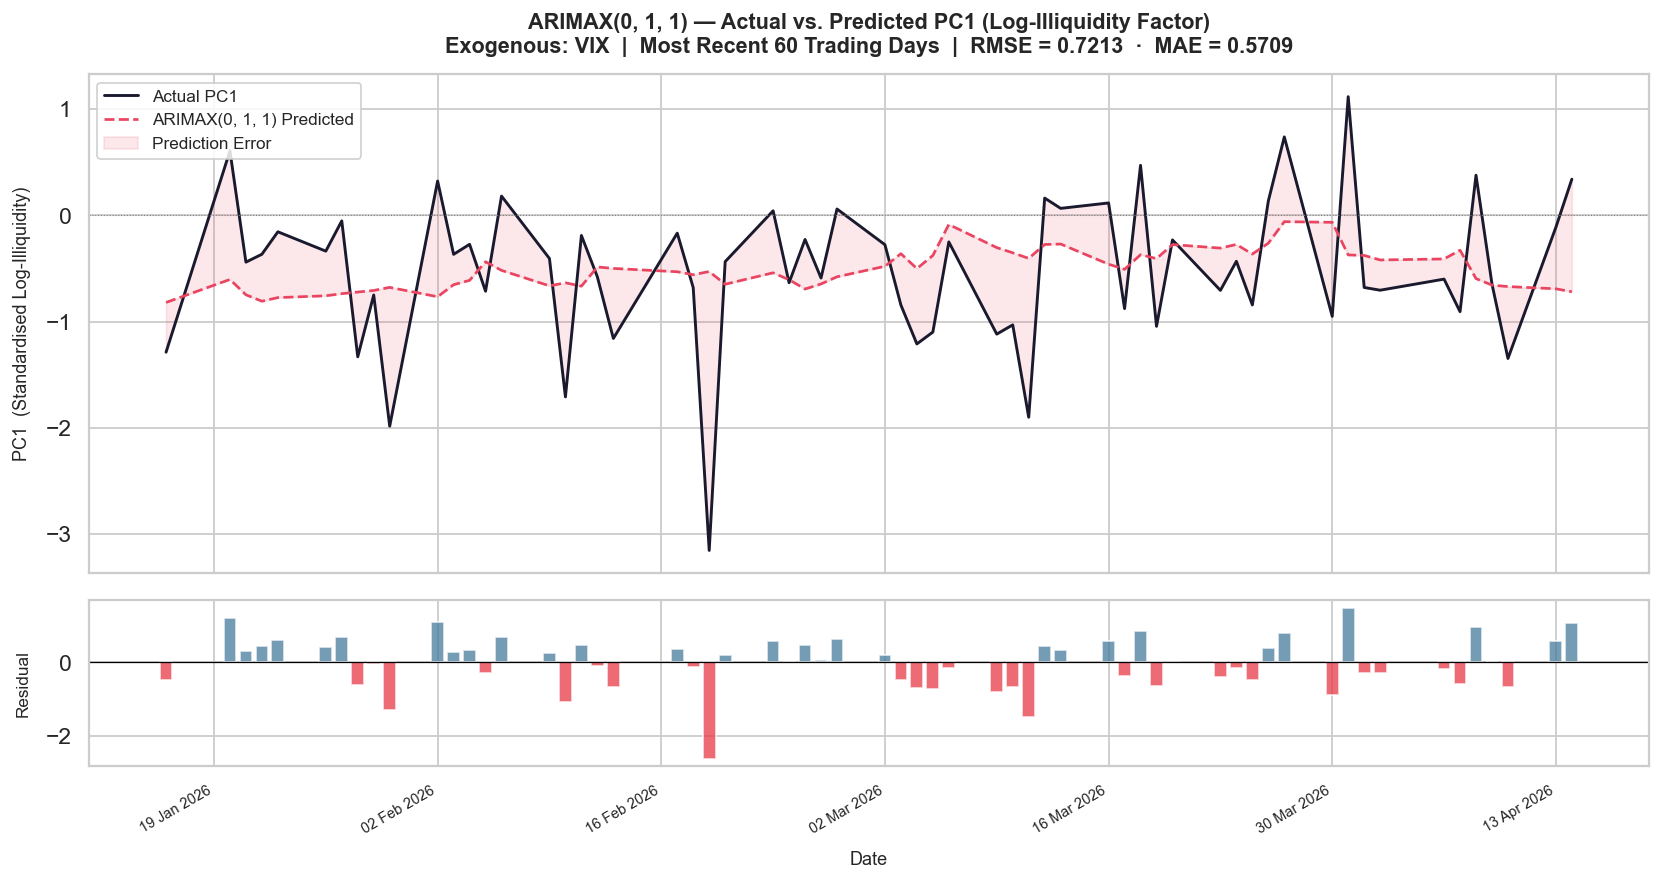

In [4]:
import itertools
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")   # suppress convergence noise during grid search

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — PCA: Reduce five log-illiquidity series → PC1
# ══════════════════════════════════════════════════════════════════════════════
# Drop any rows with NaN before scaling (the first row is always NaN because
# log returns require a prior observation).
illiq_clean = illiq_scores.dropna()

# Z-score each column so PCA is not dominated by the ticker with the largest
# absolute illiquidity level (NVDA at high price tends to have smallest raw
# ILLIQ, AAPL/MSFT tend to be larger — standardisation neutralises this).
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(illiq_clean)

pca = PCA(n_components=len(EQUITY_TICKERS))
pca.fit(X_scaled)

# PC1 is the first principal component — the linear combination that explains
# the largest share of cross-sectional variance in log-illiquidity.
pc1 = pd.Series(
    pca.transform(X_scaled)[:, 0],
    index=illiq_clean.index,
    name="PC1_LogIlliquidity",
)

explained = pca.explained_variance_ratio_
print("── PCA Explained Variance ──────────────────────────────────────────")
for i, ev in enumerate(explained, 1):
    print(f"  PC{i}: {ev:.2%}  {'◀ selected' if i == 1 else ''}")
print(f"\n  PC1 captures {explained[0]:.2%} of total log-illiquidity variance.\n")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Augmented Dickey-Fuller Test for Stationarity on PC1
# ══════════════════════════════════════════════════════════════════════════════
# H₀: unit root present (non-stationary).  Reject H₀ if p-value < 0.05.
adf_stat, adf_pval, adf_lags, adf_nobs, adf_crit, _ = adfuller(pc1, autolag="AIC")

print("── Augmented Dickey-Fuller Test on PC1 ─────────────────────────────")
print(f"  Test Statistic : {adf_stat:.4f}")
print(f"  p-value        : {adf_pval:.4f}")
print(f"  Lags Used      : {adf_lags}")
print(f"  Observations   : {adf_nobs}")
print("  Critical Values:")
for level, cv in adf_crit.items():
    print(f"    {level}: {cv:.4f}")

if adf_pval < 0.05:
    print("\n  RESULT: Reject H₀ — PC1 is STATIONARY (d = 0 is valid).")
    adf_d_max = 1   # allow d ∈ {0, 1} in the grid; model may still pick d=1
else:
    print("\n  RESULT: Fail to reject H₀ — PC1 is NON-STATIONARY (d ≥ 1 required).")
    adf_d_max = 2

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Align PC1 with VIX on a common date index
# ══════════════════════════════════════════════════════════════════════════════
vix_exog = prices["VIX"].reindex(pc1.index).ffill()

# Inner-join ensures every row has both an endogenous and exogenous value.
ts_df = pd.concat([pc1, vix_exog], axis=1, join="inner").dropna()
ts_df.columns = ["PC1", "VIX"]

endog = ts_df["PC1"]
exog  = ts_df[["VIX"]]

print(f"\n── Modelling window: {ts_df.index[0].date()} → {ts_df.index[-1].date()}")
print(f"   Observations: {len(ts_df)}\n")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — AIC Grid Search for Optimal ARIMAX(p, d, q) Order
# ══════════════════════════════════════════════════════════════════════════════
p_vals = range(0, 4)
d_vals = range(0, adf_d_max + 1)
q_vals = range(0, 4)

aic_records = []
best_aic    = np.inf
best_order  = (1, 0, 0)   # sensible default if all fits fail

print("── ARIMAX AIC Grid Search ──────────────────────────────────────────")
print(f"  Search space: p ∈ {list(p_vals)}, d ∈ {list(d_vals)}, q ∈ {list(q_vals)}")
print(f"  Total candidates: {len(p_vals) * len(d_vals) * len(q_vals)}\n")

for p, d, q in itertools.product(p_vals, d_vals, q_vals):
    # (0,0,0) with exog is just an OLS regression — valid but a useful baseline.
    try:
        fit = ARIMA(endog, exog=exog, order=(p, d, q)).fit(
            method_kwargs={"warn_convergence": False}
        )
        aic_records.append({"p": p, "d": d, "q": q, "AIC": fit.aic})
        if fit.aic < best_aic:
            best_aic   = fit.aic
            best_order = (p, d, q)
    except Exception:
        # Some (p,d,q) combinations are not identifiable — skip silently.
        continue

aic_table = (
    pd.DataFrame(aic_records)
      .sort_values("AIC")
      .reset_index(drop=True)
)

print("  Top 10 models by AIC:")
print(aic_table.head(10).to_string(index=False))
print(f"\n  ✔ Optimal order selected: ARIMAX{best_order}  (AIC = {best_aic:.4f})\n")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — Fit the Optimal ARIMAX Model
# ══════════════════════════════════════════════════════════════════════════════
best_model = ARIMA(endog, exog=exog, order=best_order).fit()

print("── ARIMAX Model Summary ────────────────────────────────────────────")
print(best_model.summary())

# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — Actual vs. Predicted: Most Recent 60 Trading Days
# ══════════════════════════════════════════════════════════════════════════════
LOOKBACK = 60

actual    = endog.iloc[-LOOKBACK:]
predicted = best_model.fittedvalues.iloc[-LOOKBACK:]
residuals = actual - predicted

rmse = np.sqrt((residuals ** 2).mean())
mae  = residuals.abs().mean()

print(f"\n── In-Sample Fit Metrics (last {LOOKBACK} days) ──────────────────────────")
print(f"  RMSE : {rmse:.6f}")
print(f"  MAE  : {mae:.6f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax_main, ax_resid) = plt.subplots(
    2, 1, figsize=(13, 7),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True,
)

# — Main panel: actual vs. predicted —
ax_main.plot(
    actual.index, actual.values,
    color="#1a1a2e", linewidth=1.6,
    label="Actual PC1",
)
ax_main.plot(
    predicted.index, predicted.values,
    color="#e94560", linewidth=1.5, linestyle="--",
    label=f"ARIMAX{best_order} Predicted",
)
ax_main.fill_between(
    actual.index, actual.values, predicted.values,
    alpha=0.12, color="#e94560", label="Prediction Error",
)

ax_main.set_title(
    f"ARIMAX{best_order} — Actual vs. Predicted PC1 (Log-Illiquidity Factor)\n"
    f"Exogenous: VIX  |  Most Recent {LOOKBACK} Trading Days  |  "
    f"RMSE = {rmse:.4f}  ·  MAE = {mae:.4f}",
    fontsize=12, fontweight="bold", pad=12,
)
ax_main.set_ylabel("PC1  (Standardised Log-Illiquidity)", fontsize=10, labelpad=8)
ax_main.legend(loc="upper left", fontsize=9.5, framealpha=0.85)
ax_main.axhline(0, color="grey", linewidth=0.6, linestyle=":")

# — Residual panel —
ax_resid.bar(
    residuals.index, residuals.values,
    color=np.where(residuals.values >= 0, "#457b9d", "#e63946"),
    width=0.8, alpha=0.75,
)
ax_resid.axhline(0, color="black", linewidth=0.7)
ax_resid.set_ylabel("Residual", fontsize=9.5, labelpad=8)
ax_resid.set_xlabel("Date", fontsize=10, labelpad=8)

# — Date formatting —
ax_resid.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
ax_resid.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
plt.setp(ax_resid.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

fig.tight_layout()
plt.show()